# Training Script - XGBoost [06.05.2026]

# Brief Note

### Updated on 14/05/2026 <br>
| Component | Status |
|-----------|--------|
| Type of Model | Customer-aware model |
| Data | 1,618 rows (1,568 real + 50 synthetic OOD) |
| Section Model | 99.59% accuracy |
| Cluster Model | 90.12% accuracy |
| KNN OOD scorer | Fitted, threshold = 0.7520 |
| Saved artifacts | `model_section.pkl`, `model_cluster.pkl`, `pipeline_config.pkl` |

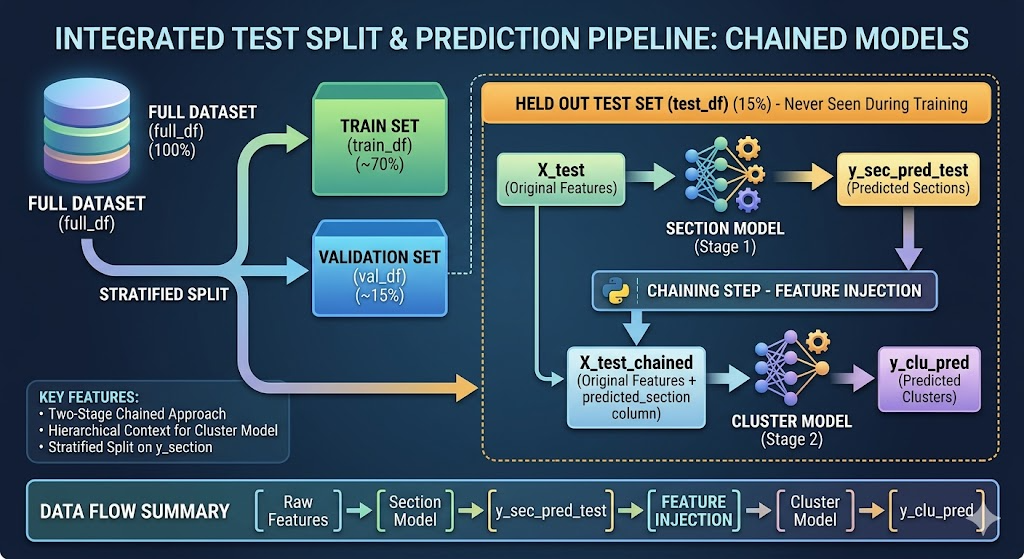

📊 Output Result (Test dataset) <br>

🔴 Case : Section ❌, Cluster ✅ <br>
🔵 Case : Section ✅, Cluster ❌

| DEVICE_ID | Actual Section | Predicted Section | Section Check | Actual Cluster | Predicted Cluster | Cluster Check |
| --------- | -------------- | ----------------- | ------------- | -------------- | ----------------- | ------------- |
| HT275     | SECTION 1      | SECTION 3         | ❌ False       | CLUSTER 1      | CLUSTER 1         | ✅ True        |
| CPM6311   | SECTION 1      | SECTION 1         | ✅ True        | CLUSTER 3      | CLUSTER 4         | ❌ False       |
| FIT151    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 4      | CLUSTER 1         | ❌ False       |
| V29011    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 7      | CLUSTER 4         | ❌ False       |




### 📋 To Do Next - SOLVED ✅

| # | Task | Status - COMPLETED ✅|
|---|------|--------|
| 1 | Cross tabulation distribution for result testing (actual vs prediction) | ✅ |
| 2 | Suggestion to create chain model (2 XGBoost model work hierarchy) | ✅ |
| 3 | Removal suffix at the model | ✅ |
| 4 | Refine Numerical Block | ✅ |
| 5 | Check whether the model is run fix by customer? | ✅ |

---

### ⚠️ Problem & Solution - SOLVED ✅

| | Details |
|---|---------|
| **Problem**  | Model developed is **not customer-specific** *(raised: 23/4/2026)* |
| **Solution** | Introduce `SafeLabelEncoder` — a new class, drop-in replacement that wraps sklearn's `LabelEncoder` and adds an `__UNKNOWN__` class at fit time |

---

### 🔗 Model Architecture

| Type | Description |
|------|-------------|
| **2 Model** | Train and predict Section & Cluster **separately** |
| **Chain Model** | Train 2 models and **link** the Section → Cluster output |

---

### ✅ Inference Checklist (Application Side)

| Step | Action | Checklist |
|------|--------|--------|
| 1 | Load `pipeline_config.pkl` |✅ |
| 2 | Load `model_section.pkl` and `model_cluster.pkl` |✅ |
| 3 | Call `predict_safe()` — **never** call `model.predict()` directly |✅ |
| 4 | If `pred_section == 'UNKNOWN'`: customer is not in training set — **do NOT** surface a predicted cluster |✅ |
| 5 | To support a new customer: retrain with their data included and re-export `pipeline_config.pkl` |✅ |


### 🗓️ OOD Improvement Roadmap

| Phase | # | Action | Purpose | Status |
|-------|---|--------|---------|--------|
| **Today** | 1 | Add width gate in `check_entities()` | Blocks weird inputs immediately | ✅ Done |
| **Today** | 2 | Inject synthetic OOD rows | Model learns to flag unknown inputs | ✅ Done |
| **Today** | 3 | Retrain | Model now has the split node | ✅ Done |
| **Ongoing** | 4 | Log every blocked device | Collect real OOD examples | ✅ Done |
| **Ongoing** | 5 | Human labels them | Establish ground truth | ⏳ Pending |
| **Ongoing** | 6 | Add to training data | Replace synthetic with real examples | ❌ Not started |
| **Ongoing** | 7 | Retrain quarterly | Model improves over time | ❌ Not started |


# SCRIPT 6 (5.5.2026 15:30)

# 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import random
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# %%
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)

folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")

if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")

df = pd.concat(dfs, ignore_index=True)

print(f"\n   Total records : {len(df)}")
print(f"   Columns       : {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")



📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows

   Total records : 1568
   Columns       : CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0   OILTEK   A1706  SECTION 1  CLUSTER 1      A500
1   OILTEK   A1706  SECTION 1  CLUSTER 1     HT500
2   OILTEK   A1706  SECTION 1  CLUSTER 1    PT500A
3   OILTEK   A1706  SECTION 1  CLUSTER 1    PV500B
4   OILTEK   A1706  SECTION 1  CLUSTER 1     TE500
5   OILTEK   A1706  SECTION 2  CLUSTER 1    HLA600
6   OILTEK   A1706  SECTION 2  CLUSTER 1 

# 2. SafeLabelEncoder

In [2]:


# %%
class SafeLabelEncoder:
    """
    A LabelEncoder that:
      - Adds an '__UNKNOWN__' class during fit.
      - Returns the index of '__UNKNOWN__' for any unseen label during transform, instead of crashing.
      - Provides is_known(values) for explicit gate checks.

    Usage is identical to LabelEncoder:
        le = SafeLabelEncoder()
        le.fit(series)
        encoded = le.transform(series)
        decoded = le.inverse_transform(encoded_array)
    """

    UNKNOWN_LABEL = "__UNKNOWN__"

    # initialize encoder and class storage
    def __init__(self):
        self._le      = LabelEncoder()
        self.classes_ = None

    # learn unique labels and include UNKNOWN
    def fit(self, y):
        labels = list(pd.Series(y).astype(str).unique())
        if self.UNKNOWN_LABEL not in labels:
            labels = [self.UNKNOWN_LABEL] + labels
        self._le.fit(labels)
        self.classes_ = self._le.classes_
        return self

    # convert input to encoded values (handle unknowns)
    def transform(self, y):
        y_str  = pd.Series(y).astype(str)
        known  = set(self.classes_)
        y_safe = y_str.where(y_str.isin(known), other=self.UNKNOWN_LABEL)
        return self._le.transform(y_safe)

    # fit and transform in one step
    def fit_transform(self, y):
        return self.fit(y).transform(y)

    # decode values back to original labels
    def inverse_transform(self, y):
        return self._le.inverse_transform(y)

    # check if values are known (exclude UNKNOWN)
    def is_known(self, values):
        """Return a boolean Series: True if value is known (not __UNKNOWN__)."""
        known = set(self.classes_) - {self.UNKNOWN_LABEL}
        return pd.Series(values).astype(str).isin(known)

    # get classes excluding UNKNOWN label
    def real_classes(self):
        """Return classes excluding the __UNKNOWN__ sentinel."""
        return [c for c in self.classes_ if c != self.UNKNOWN_LABEL]



# 3. Feature Engineering

In [3]:
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)")
print("=" * 100)

# ── Extraction functions ──────────────────────────────────────

def extract_numeric_block(device_id):
    """First number as integer — strips leading zeros.
    e.g. 'LL0000000021' → 21
    """
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

def extract_numeric_string(device_id):
    """Raw digit string preserving leading zeros.
    e.g. 'LL0000000021' → '0000000021'
    """
    match = re.search(r'\d+', str(device_id))
    return match.group() if match else ''

def extract_suffix_letters(device_id):
    """Letters immediately after the trailing number.
    e.g. 'M051A' → 'A'
    """
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_full(device_id):
    """Everything after the trailing number.
    e.g. 'M051A' → 'A'
    """
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

def extract_section_num(section_str):
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

def extract_cluster_num(cluster_str):
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0

# ── Numeric block features ────────────────────────────────────
df['numeric_block']         = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)
df['suffix_full']           = df['DEVICE_ID'].apply(extract_suffix_full)
df['device_id_length']      = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter']     = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']           = (df['numeric_block'] != -1).astype(int)

# ── Numeric block convention fingerprint ──────────────────────
# Leading zeros ARE meaningful — they encode field width and
# padding depth which varies by project and naming convention.
# e.g. "FF051" (count_num_digit=3) vs "LL0000000021" (count_num_digit=10)
print("\n   Creating numeric block convention features...")

_numeric_raw_str              = df['DEVICE_ID'].apply(extract_numeric_string)

df['count_num_digit']         = _numeric_raw_str.str.len()                                               # Full field width including leading zeros  e.g. "051"→3, "0000000021"→10
df['numeric_remove_zero']     = df['numeric_block']                                                       # Significant value — int() already strips leading zeros
df['count_num_remove_zero']   = df['numeric_remove_zero'].apply(lambda x: len(str(x)) if x != -1 else 0) # Digit count of significant value  e.g. 51→2, 1→1, 21→2
df['leading_zero_count']      = df['count_num_digit'] - df['count_num_remove_zero']                       # Padding depth  e.g. "051"→1, "001"→2, "0000000021"→8

print("   ✅ Numeric block convention features created")

# ── Advanced suffix features ──────────────────────────────────
print("\n   Creating advanced suffix features...")

df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d',       regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.',        regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)
df['suffix_last_char']          = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']= df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit'] = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)
df['equip_id_length']           = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']      = df['DEVICE_ID'].astype(str).str.count(r'\d')

print("   ✅ Advanced suffix features created")

# ── Numeric block rank within project ────────────────────────
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(
    ['CUSTOMER', 'PROJECT'], group_keys=False
).apply(assign_block_rank)

print("   ✅ numeric_block_rank created")


# ── Same numeric block, different section/cluster across customers/projects ──
print(f"\n{'NUMERIC_BLOCK':>15} | {'LOCATION 1':^50} | {'LOCATION 2':^50}")
print("-" * 120)

found = 0
for nb, group in df.groupby('numeric_block'):
    combos = (
        group[['CUSTOMER', 'PROJECT', 'SECTION', 'CLUSTER']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    unique_sections = combos['SECTION'].unique()

    if len(unique_sections) < 2:
        continue  # same number maps to same section everywhere — skip

    combo_list = combos.to_dict('records')
    for i in range(len(combo_list)):
        for j in range(i + 1, len(combo_list)):
            loc1 = combo_list[i]
            loc2 = combo_list[j]
            if loc1['SECTION'] != loc2['SECTION'] or loc1['CLUSTER'] != loc2['CLUSTER']:
                l1 = f"{loc1['SECTION']}, {loc1['CLUSTER']}  ({loc1['CUSTOMER']} - {loc1['PROJECT']})"
                l2 = f"{loc2['SECTION']}, {loc2['CLUSTER']}  ({loc2['CUSTOMER']} - {loc2['PROJECT']})"
                print(f"{nb:>15} | {l1:<50} | {l2:<50}")
                found += 1

print("-" * 120)
print(f"\n  Total conflicting numeric blocks found : {found}")



🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)

   Creating numeric block convention features...
   ✅ Numeric block convention features created

   Creating advanced suffix features...
   ✅ Advanced suffix features created
   ✅ numeric_block_rank created

  NUMERIC_BLOCK |                     LOCATION 1                     |                     LOCATION 2                    
------------------------------------------------------------------------------------------------------------------------
              1 | SECTION 3, CLUSTER 1  (OILTEK - A1706)             | SECTION 3, CLUSTER 2  (OILTEK - A1706)            
              1 | SECTION 3, CLUSTER 1  (OILTEK - A1706)             | SECTION 4, CLUSTER 1  (OILTEK - A1706)            
              1 | SECTION 3, CLUSTER 1  (OILTEK - A1706)             | SECTION 4, CLUSTER 2  (OILTEK - A1706)            
              1 | SECTION 3, CLUSTER 1  (OILTEK - A1706)             | SECTION 4, CLUSTER 3  (OILTEK - A1706)       

In [4]:
# ── Shape feature (numeric suffix) ───────────────────────────
print("\n   Creating numeric suffix shape feature...")

def extract_numeric_suffix_shape(device_id):
    match = re.search(r'\d.*', str(device_id))
    if not match:
        return 'NODIGIT'
    return ''.join('L' if c.isalpha() else 'D' for c in match.group())

df['numeric_suffix_shape'] = df['DEVICE_ID'].apply(extract_numeric_suffix_shape)
print("   ✅ numeric_suffix_shape created")
print(f"\n   Sample shapes:")
print(df[['DEVICE_ID', 'numeric_suffix_shape']].drop_duplicates().head(12).to_string(index=False))


   Creating numeric suffix shape feature...
   ✅ numeric_suffix_shape created

   Sample shapes:
DEVICE_ID numeric_suffix_shape
     A500                  DDD
    HT500                  DDD
   PT500A                 DDDL
   PV500B                 DDDL
    TE500                  DDD
   HLA600                  DDD
    DV601                  DDD
    FB601                  DDD
   HLA601                  DDD
   LLA601                  DDD
  LSH601A                 DDDL
  LSL601A                 DDDL


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CUSTOMER                    1568 non-null   object
 1   PROJECT                     1568 non-null   object
 2   SECTION                     1568 non-null   object
 3   CLUSTER                     1568 non-null   object
 4   DEVICE_ID                   1568 non-null   object
 5   numeric_block               1568 non-null   int64 
 6   device_suffix_letter        1568 non-null   object
 7   suffix_full                 1568 non-null   object
 8   device_id_length            1568 non-null   int64 
 9   has_suffix_letter           1568 non-null   int64 
 10  has_numeric                 1568 non-null   int64 
 11  count_num_digit             1568 non-null   int64 
 12  numeric_remove_zero         1568 non-null   int64 
 13  count_num_remove_zero       1568 non-null   int6

In [6]:
df5 = df[['CUSTOMER', 'PROJECT', 'SECTION', 'CLUSTER', 'DEVICE_ID', 'numeric_block']].copy()
df5['sec_clus'] = df5['SECTION'] + ' ' + df5['CLUSTER']

# keep only numeric_block that appears in more than one unique sec_clus
multi_sec_clus = df5.groupby('numeric_block')['sec_clus'].nunique()
valid_numeric = multi_sec_clus[multi_sec_clus > 1].index

df6 = df5[df5['numeric_block'].isin(valid_numeric)]\
         .drop_duplicates(subset=['numeric_block', 'sec_clus'])\
         [['DEVICE_ID', 'PROJECT', 'sec_clus', 'numeric_block']]\
         .sort_values(['numeric_block', 'PROJECT'], ascending=True)
df6


# df6.to_excel(r'C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\output_prediction\testing distribution cluster section\replicate_numeric_block.xlsx', index=False)

df5['numeric_full'] = df5['DEVICE_ID'].str.extract(r'(\d+)')
df6 = df5[df5['numeric_block'].isin(valid_numeric)]\
         .drop_duplicates(subset=['numeric_block', 'sec_clus'])\
         [['numeric_full', 'numeric_block', 'DEVICE_ID', 'PROJECT', 'sec_clus']]\
         .sort_values('numeric_block', ascending=True)

# df6.to_excel(r'C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\output_prediction\testing distribution cluster section\replicate_numeric_block1.xlsx', index=False)


# 4. Label Encoding

In [7]:
print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)")
print("=" * 100)

le_suffix_letter  = SafeLabelEncoder()
le_suffix_last    = SafeLabelEncoder()
le_section        = SafeLabelEncoder()
le_cluster        = SafeLabelEncoder()
le_customer       = SafeLabelEncoder()
le_shape          = SafeLabelEncoder()

df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])
df['customer_enc']         = le_customer.fit_transform(df['CUSTOMER'])
df['shape_enc']            = le_shape.fit_transform(df['numeric_suffix_shape'])

print(f"   Section classes  : {list(le_section.classes_)}")
print(f"   Cluster classes  : {list(le_cluster.classes_)}")
print(f"   Customer classes : {list(le_customer.classes_)}")
print(f"   Shape classes    : {list(le_shape.classes_)}")


# %% [markdown]
# # 4b. Synthetic OOD Injection
# WHY   : count_num_digit has no variance (always 3) → ignored by XGBoost
# EFFECT: wide inputs (e.g. width=10) go to default leaf → overconfident
# HOW   : add synthetic wide-width rows labeled __OOD__ → create variance → enable split
# RESULT: wide inputs routed to OOD instead of normal classes
# NOTE  : __OOD__ maps to __UNKNOWN__ via existing encoders

# %%
print("\n" + "=" * 100)
print("🧪 INJECTING SYNTHETIC OUT-OF-DISTRIBUTION (OOD) ROWS")
print("=" * 100)

random.seed(42)

# ── Discover numeric width distribution BEFORE injection ─────
numeric_width_dist_real = df['count_num_digit'].value_counts().sort_index()
known_num_widths_real   = set(df['count_num_digit'].unique())
max_num_width_real      = int(df['count_num_digit'].max())

min_coverage    = max(1, int(len(df) * 0.01))
reliable_widths = set(numeric_width_dist_real[numeric_width_dist_real >= min_coverage].index.tolist())

print(f"\n   Numeric field width distribution (real training data):")
print(numeric_width_dist_real.to_string())
print(f"\n   Known widths (all seen)      : {sorted(known_num_widths_real)}")
print(f"   Reliable widths (>= 1% data) : {sorted(reliable_widths)}")
print(f"   Max width seen               : {max_num_width_real}")


def generate_ood_device_id(real_max_width, min_extra=4, max_extra=10):
    """Generate a device ID whose numeric field is wider than anything seen in training."""
    prefixes = ['XX', 'YY', 'ZZ', 'AA', 'BB']
    prefix   = random.choice(prefixes)
    n_digits = random.randint(real_max_width + min_extra, real_max_width + max_extra)
    number   = str(random.randint(1, 10 ** max(1, n_digits - 2))).zfill(n_digits)
    return f"{prefix}{number}"


n_real_min           = df['SECTION'].value_counts().min()
n_synthetic          = max(50, int(n_real_min * 0.15))
placeholder_customer = df['CUSTOMER'].iloc[0]
placeholder_project  = df['PROJECT'].iloc[0]

synthetic_rows = []
for _ in range(n_synthetic):
    synthetic_rows.append({
        'CUSTOMER'  : placeholder_customer,
        'PROJECT'   : placeholder_project,
        'DEVICE_ID' : generate_ood_device_id(max_num_width_real),
        'SECTION'   : '__OOD__',
        'CLUSTER'   : '__OOD__',
    })

df_synthetic = pd.DataFrame(synthetic_rows)

# ── Compute features for synthetic rows ──────────────────────
df_synthetic['numeric_block']        = df_synthetic['DEVICE_ID'].apply(extract_numeric_block)
df_synthetic['device_suffix_letter'] = df_synthetic['DEVICE_ID'].apply(extract_suffix_letters)
df_synthetic['suffix_full']          = df_synthetic['DEVICE_ID'].apply(extract_suffix_full)
df_synthetic['device_id_length']     = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['has_suffix_letter']    = (df_synthetic['device_suffix_letter'] != '').astype(int)
df_synthetic['has_numeric']          = (df_synthetic['numeric_block'] != -1).astype(int)

_syn_raw_str = df_synthetic['DEVICE_ID'].apply(extract_numeric_string)
df_synthetic['count_num_digit']       = _syn_raw_str.str.len()
df_synthetic['numeric_remove_zero']   = df_synthetic['numeric_block']
df_synthetic['count_num_remove_zero'] = df_synthetic['numeric_remove_zero'].apply(lambda x: len(str(x)) if x != -1 else 0)
df_synthetic['leading_zero_count']    = df_synthetic['count_num_digit'] - df_synthetic['count_num_remove_zero']
df_synthetic['suffix_length']         = df_synthetic['suffix_full'].astype(str).str.len()
df_synthetic['suffix_has_digit']      = df_synthetic['suffix_full'].astype(str).str.contains(r'\d',       regex=True).astype(int)
df_synthetic['suffix_has_letter']     = df_synthetic['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df_synthetic['suffix_has_decimal']    = df_synthetic['suffix_full'].astype(str).str.contains(r'\.',        regex=True).astype(int)
df_synthetic['suffix_digit_count']    = df_synthetic['suffix_full'].astype(str).str.count(r'\d')
df_synthetic['suffix_letter_count']   = df_synthetic['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df_synthetic['suffix_starts_with_digit']   = df_synthetic['suffix_full'].apply(lambda s: 1 if len(str(s)) > 0 and str(s)[0].isdigit() else 0)
df_synthetic['suffix_last_char']           = df_synthetic['suffix_full'].apply(lambda s: str(s)[-1] if len(str(s)) > 0 else '')
df_synthetic['suffix_last_char_is_letter'] = df_synthetic['suffix_last_char'].apply(lambda c: 1 if isinstance(c, str) and c.isalpha() else 0)
df_synthetic['suffix_last_char_is_digit']  = df_synthetic['suffix_last_char'].apply(lambda c: 1 if isinstance(c, str) and c.isdigit() else 0)
df_synthetic['equip_id_length']            = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['equip_id_digit_count']       = df_synthetic['DEVICE_ID'].astype(str).str.count(r'\d')
df_synthetic['numeric_block_rank']         = 1

# ── Encode using already-fitted encoders ──────────────────────
df_synthetic['suffix_letter_enc']    = le_suffix_letter.transform(df_synthetic['device_suffix_letter'])
df_synthetic['suffix_last_char_enc'] = le_suffix_last.transform(df_synthetic['suffix_last_char'])
df_synthetic['section_enc']          = le_section.transform(df_synthetic['SECTION'])
df_synthetic['cluster_enc']          = le_cluster.transform(df_synthetic['CLUSTER'])
df_synthetic['numeric_suffix_shape'] = df_synthetic['DEVICE_ID'].apply(extract_numeric_suffix_shape)
df_synthetic['shape_enc']            = le_shape.transform(df_synthetic['numeric_suffix_shape'])

# ── Merge into main dataframe ─────────────────────────────────
df = pd.concat([df, df_synthetic], ignore_index=True)

df['section_enc'] = df['section_enc'].fillna(le_section.transform(['__UNKNOWN__'])[0]).astype(int)
df['cluster_enc'] = df['cluster_enc'].fillna(le_cluster.transform(['__UNKNOWN__'])[0]).astype(int)
df['shape_enc']   = df['shape_enc'].fillna(le_shape.transform(['__UNKNOWN__'])[0]).astype(int)

print(f"\n   ✅ Injected {n_synthetic} synthetic OOD rows")
print(f"   ✅ New df shape          : {df.shape}")
print(f"\n   Numeric width distribution (real + OOD combined):")
print(df['count_num_digit'].value_counts().sort_index().to_string())
print(f"\n   Sample synthetic OOD rows:")
print(df_synthetic[['DEVICE_ID', 'count_num_digit', 'leading_zero_count',
                     'SECTION', 'CLUSTER']].head(8).to_string(index=False))



🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)
   Section classes  : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6'), np.str_('__UNKNOWN__')]
   Cluster classes  : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9'), np.str_('__UNKNOWN__')]
   Customer classes : [np.str_('OILTEK'), np.str_('UGS'), np.str_('__UNKNOWN__')]
   Shape classes    : [np.str_('D'), np.str_('DD'), np.str_('DDD'), np.str_('DDDD'), np.str_('DDDDD'), np.str_('DDDDDD'), np.str_('DDDDDL'), np.str_('DDDDL'), np.str_('DDDL'), np.str_('DDDLL'), np.str_('DDLLD'), np.str_('DDLLDD'), np.str_('DDLLDDLL'), np.str_('DDLLDL'), np.str_('DDLLDLL'), np.str_('DDLLLDL'), np.str_('__UNKNOWN__')]

🧪 INJECTING SYNTHETIC OUT-OF-DISTRIBUTION (OOD) ROWS

   Numeric field width distribution 

# 5. Features & Targets

In [8]:
# Built AFTER OOD injection — X always reflects the full dataset.

print("\n" + "=" * 100)
print("🎯 FEATURES & TARGETS")
print("=" * 100)

feature_columns = [
    # ── Numeric block: raw ───────────────────────────────────
    'numeric_block',

    # ── Numeric block: convention fingerprint ────────────────
    'count_num_digit',
    'count_num_remove_zero',
    'numeric_remove_zero',
    'leading_zero_count',
    'customer_enc',

    # ── Device ID structural ─────────────────────────────────
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    'equip_id_length',
    'equip_id_digit_count',

    # ── Suffix features ──────────────────────────────────────
    'suffix_letter_enc',
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',

    # ── Shape feature ─────────────────────────────────────────
    'shape_enc',
]

X         = df[feature_columns]
y_section = df['section_enc'].astype(int)
y_cluster = df['cluster_enc'].astype(int)

print(f"   Total features : {len(feature_columns)}")
print(f"   X shape        : {X.shape}")
print(f"   y_section dist : {pd.Series(y_section).value_counts().sort_index().to_dict()}")



🎯 FEATURES & TARGETS
   Total features : 23
   X shape        : (1618, 23)
   y_section dist : {0: 475, 1: 358, 2: 303, 3: 156, 4: 252, 5: 24, 6: 50}


# 6. Chain Model (Train, Val, Test)

In [9]:
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)

# ── NaN check before split ────────────────────────────────────
print("\n   Pre-split target diagnostics:")
print(f"   y_section NaN : {y_section.isna().sum()}")
print(f"   y_cluster  NaN : {y_cluster.isna().sum()}")

y_section = y_section.fillna(le_section.transform(['__UNKNOWN__'])[0]).astype(int)
y_cluster  = y_cluster.fillna(le_cluster.transform(['__UNKNOWN__'])[0]).astype(int)

print(f"   y_section NaN after fill : {y_section.isna().sum()}  ✅")
print(f"   y_cluster  NaN after fill : {y_cluster.isna().sum()}  ✅")
print(f"   y_section unique : {sorted(y_section.unique())}")
print(f"   y_cluster  unique : {sorted(y_cluster.unique())}")


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y           = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        idx_tmp, idx_test = train_test_split(
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )
        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df           = df.loc[idx_train].copy().reset_index(drop=False)
    val_df             = df.loc[idx_val].copy().reset_index(drop=False)
    test_df            = df.loc[idx_test].copy().reset_index(drop=False)
    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


full_df              = X.copy()
full_df["DEVICE_ID"] = df["DEVICE_ID"].values
full_df["y_section"] = y_section.values   # .values avoids index mismatch
full_df["y_cluster"] = y_cluster.values

train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

feature_cols = X.columns.tolist()


def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    return X_out.fillna(0)


X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"].astype(int)
y_sec_val   = val_df["y_section"].astype(int)
y_sec_test  = test_df["y_section"].astype(int)
y_clu_train = train_df["y_cluster"].astype(int)
y_clu_val   = val_df["y_cluster"].astype(int)
y_clu_test  = test_df["y_cluster"].astype(int)

print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")

# NaN verification per split
for name, y in [("y_sec_train", y_sec_train), ("y_sec_val",  y_sec_val),
                ("y_sec_test",  y_sec_test),  ("y_clu_train", y_clu_train),
                ("y_clu_val",   y_clu_val),   ("y_clu_test",  y_clu_test)]:
    n_nan  = y.isna().sum()
    status = "✅" if n_nan == 0 else f"⚠ {n_nan} NaN"
    print(f"   {name:15s} : {status}")


# ============================================================
# 🚀 STAGE 1 — SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 1 — TRAINING SECTION MODEL")
print("=" * 100)

# note : model is developed with multiple regularization techniques.
# Not explicitly using L1/L2 regularization.
# The model handles OOD with KNN layer on top.
def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,               # prevent overly deep trees (structural regularization)
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,             # stochastic regularization — 80% data per tree
        colsample_bytree = 0.8,             # feature-level regularization — 80% features per tree
        gamma            = 0.1,             # split regularization — min loss reduction to split
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )


# Exclude __UNKNOWN__ from class count — sentinel only, not a real class
n_section_classes = len(le_section.classes_)
n_cluster_classes = len(le_cluster.classes_)

model_section = build_model(n_section_classes)
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

y_sec_pred_train = model_section.predict(X_train)
y_sec_pred_val   = model_section.predict(X_val)
y_sec_pred_test  = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred_test):.2%}")

sec_labels = sorted(set(y_sec_test) | set(y_sec_pred_test))
print(classification_report(
    y_sec_test, y_sec_pred_test,
    labels=sec_labels,
    target_names=[le_section.classes_[i] for i in sec_labels],
    zero_division=0
))


# ============================================================
# 🔗 CHAIN — INJECT SECTION PREDICTION INTO CLUSTER FEATURES
# ============================================================
print("\n" + "=" * 100)
print("🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES")
print("=" * 100)

X_train_chained                      = X_train.copy()
X_val_chained                        = X_val.copy()
X_test_chained                       = X_test.copy()
X_train_chained["predicted_section"] = y_sec_pred_train
X_val_chained["predicted_section"]   = y_sec_pred_val
X_test_chained["predicted_section"]  = y_sec_pred_test

print(f"   ✅ Feature shape after chaining: {X_train_chained.shape}")


# ============================================================
# 🚀 STAGE 2 — CLUSTER MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 2 — TRAINING CLUSTER MODEL")
print("=" * 100)

model_cluster = build_model(n_cluster_classes)
model_cluster.fit(
    X_train_chained, y_clu_train,
    eval_set=[(X_train_chained, y_clu_train), (X_val_chained, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test_chained)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")

clu_labels = sorted(set(y_clu_test) | set(y_clu_pred))
print(classification_report(
    y_clu_test, y_clu_pred,
    labels=clu_labels,
    target_names=[le_cluster.classes_[i] for i in clu_labels],
    zero_division=0
))

print("\n" + "=" * 100)
print("📋 CHAINED MODEL SUMMARY")
print("=" * 100)
print(f"   Stage 1 — Section Model : {accuracy_score(y_sec_test, y_sec_pred_test):.2%} accuracy")
print(f"   Stage 2 — Cluster Model : {accuracy_score(y_clu_test, y_clu_pred):.2%} accuracy")
print(f"\n   Chain flow:")
print(f"      X_features → [Section Model] → predicted_section")
print(f"      X_features + predicted_section → [Cluster Model] → predicted_cluster")




✂️  SPLITTING DATA

   Pre-split target diagnostics:
   y_section NaN : 0
   y_cluster  NaN : 0
   y_section NaN after fill : 0  ✅
   y_cluster  NaN after fill : 0  ✅
   y_section unique : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   y_cluster  unique : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
   ✅ Valid split on attempt 1

   Train : 1,133 rows
   Val   : 242 rows
   Test  : 243 rows
   Feature shape (train) : (1133, 23)
   y_sec_train     : ✅
   y_sec_val       : ✅
   y_sec_test      : ✅
   y_clu_train     : ✅
   y_clu_val       : ✅
   y_clu_test      : ✅

🚀 STAGE 1 — TRAINING SECTION MODEL

   🎯 Section Test Accuracy: 99.59%
              precision    recall  f1-score   support

   SECTION 1       0.99      1.00      0.99        71
   SECTION 2       1.00      0.98      0.99        54
   SECTION 3       1.00      1.00      1.00        45
   SEC

# 6.1 Threshold sensitivity table

In [10]:
# ── Compute test confidence scores (needed for sensitivity table) ──
sec_proba_test = model_section.predict_proba(X_test)
sec_conf_test  = sec_proba_test.max(axis=1)

# ── Threshold sensitivity table ────────────────────────────────────
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

print(f"\n{'Threshold':>10} {'Coverage':>10} {'Precision':>10} {'To Manual':>10}")
print("-" * 45)

for t in thresholds:
    mask      = sec_conf_test >= t
    coverage  = mask.sum() / len(sec_conf_test)
    precision = (y_sec_pred_test[mask] == y_sec_test.values[mask]).mean() if mask.sum() > 0 else 0
    print(f"{t*100:>9.0f}%  {coverage*100:>9.1f}%  {precision*100:>9.1f}%  {(1-coverage)*100:>9.1f}%")


 Threshold   Coverage  Precision  To Manual
---------------------------------------------
       50%      100.0%       99.6%        0.0%
       55%      100.0%       99.6%        0.0%
       60%      100.0%       99.6%        0.0%
       65%       99.6%       99.6%        0.4%
       70%       99.6%       99.6%        0.4%
       75%       99.6%       99.6%        0.4%
       80%       99.6%       99.6%        0.4%


# 6b. KNN OOD Distance Scorer

In [11]:
# PURPOSE:
#   XGBoost cannot express uncertainty for out-of-distribution inputs.
#   It silently routes them to the nearest leaf and returns whatever
#   confidence was stored there during training — often 90%+.
#
#   KNN distance scoring is a post-hoc layer that measures how far
#   a new device is from the training distribution in feature space.
#   Far device → high distance → confidence penalised downward.
#
# HOW:
#   1. Fit StandardScaler + KNN (k=5, Euclidean) on REAL training
#      rows only (OOD synthetic rows excluded).
#   2. Compute average distance of each training point to its 5
#      nearest neighbours → take 95th percentile as OOD threshold.
#   3. Save scaler, KNN, features, and threshold into pipeline_config
#      for use at inference time in the application script.
#
# RESULT:
#   LL001             distance small  → no/low penalty → 97% stays ~95%
#   LL0000000021      distance large  → heavy penalty  → 97% drops ~19%
#   LL00000000102837  distance larger → max penalty    → 97% drops ~8%

# %%
print("\n" + "=" * 100)
print("📐 FITTING KNN OOD DISTANCE SCORER")
print("=" * 100)

OOD_FEATURES = [
    'count_num_digit',        # primary signal — full field width
    'leading_zero_count',     # primary signal — padding depth
    'count_num_remove_zero',  # secondary — significant digit count
]

# ── Use REAL training rows only ───────────────────────────────
# Exclude synthetic OOD rows — KNN must represent the real
# training distribution only. OOD rows were encoded as
# __UNKNOWN__ index by SafeLabelEncoder.
unknown_enc  = int(le_section.transform(['__UNKNOWN__'])[0])
real_mask    = y_sec_train != unknown_enc
X_train_real = (
    X_train[real_mask][OOD_FEATURES]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

print(f"\n   Real training rows for KNN  : {real_mask.sum():,}")
print(f"   Synthetic rows excluded     : {(~real_mask).sum():,}")
print(f"   OOD features used           : {OOD_FEATURES}")

# ── Fit StandardScaler ────────────────────────────────────────
# Scaling is critical — without it, numeric_block (range 1–1000)
# would dominate count_num_digit (range 1–6).
ood_scaler         = StandardScaler()
X_train_ood_scaled = ood_scaler.fit_transform(X_train_real)

print(f"\n   Feature means after scaling  : {ood_scaler.mean_.round(3)}")
print(f"   Feature stds  after scaling  : {ood_scaler.scale_.round(3)}")

# ── Fit KNN ───────────────────────────────────────────────────
ood_knn = NearestNeighbors(n_neighbors=5, metric='euclidean', n_jobs=-1)
ood_knn.fit(X_train_ood_scaled)

# ── Compute distance threshold ────────────────────────────────
# 95th percentile of training distances = outer boundary of "normal".
# At inference: distance > threshold → device is OOD → penalise.
train_distances, _ = ood_knn.kneighbors(X_train_ood_scaled)
train_avg_dist     = train_distances.mean(axis=1)



# 95th pct is 0 when training data is perfectly clustered (all same width).
# Fall back to max observed distance as the reference scale.
_p95 = float(np.percentile(train_avg_dist, 95))
_max = float(train_avg_dist.max())
ood_threshold = _p95 if _p95 > 0 else (_max if _max > 0 else 1.0)

print(f"      95th %  : {_p95:.4f}")
print(f"      Max     : {_max:.4f}")
print(f"\n   ✅ OOD threshold (effective): {ood_threshold:.4f}  ← uses max since 95th pct = 0")


print(f"\n   Training distance distribution:")
print(f"      Min     : {train_avg_dist.min():.4f}")
print(f"      Mean    : {train_avg_dist.mean():.4f}")
print(f"      Median  : {np.median(train_avg_dist):.4f}")
print(f"      95th %  : {ood_threshold:.4f}  ← OOD threshold")
print(f"      Max     : {train_avg_dist.max():.4f}")
print(f"\n   ✅ KNN OOD scorer fitted")
print(f"   ✅ OOD threshold : {ood_threshold:.4f}")
print(f"\n   Interpretation:")
print(f"      distance <= {ood_threshold:.3f}  → within training distribution → no/low penalty")
print(f"      distance >  {ood_threshold:.3f}  → outside training distribution → confidence penalised")




📐 FITTING KNN OOD DISTANCE SCORER

   Real training rows for KNN  : 1,098
   Synthetic rows excluded     : 35
   OOD features used           : ['count_num_digit', 'leading_zero_count', 'count_num_remove_zero']

   Feature means after scaling  : [3.253 0.223 3.03 ]
   Feature stds  after scaling  : [1.116 0.425 1.141]
      95th %  : 0.0000
      Max     : 0.7520

   ✅ OOD threshold (effective): 0.7520  ← uses max since 95th pct = 0

   Training distance distribution:
      Min     : 0.0000
      Mean    : 0.0032
      Median  : 0.0000
      95th %  : 0.7520  ← OOD threshold
      Max     : 0.7520

   ✅ KNN OOD scorer fitted
   ✅ OOD threshold : 0.7520

   Interpretation:
      distance <= 0.752  → within training distribution → no/low penalty
      distance >  0.752  → outside training distribution → confidence penalised


# 7. Chain Model Output

In [12]:
# ============================================================
# 📋 RESULT DATAFRAME — CHAINED MODEL PREDICTIONS
# ============================================================

# ✅ TRAIN
train_df2                    = train_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
train_df2["actual_section"]  = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"]  = le_cluster.inverse_transform(train_df2["y_cluster"])
train_df2["pred_section"]    = le_section.inverse_transform(y_sec_pred_train)
train_df2["pred_cluster"]    = le_cluster.inverse_transform(model_cluster.predict(X_train_chained))
train_df2["section_correct"] = train_df2["actual_section"] == train_df2["pred_section"]
train_df2["cluster_correct"] = train_df2["actual_cluster"] == train_df2["pred_cluster"]

# ✅ VAL
val_df2                    = val_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
val_df2["actual_section"]  = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"]  = le_cluster.inverse_transform(val_df2["y_cluster"])
val_df2["pred_section"]    = le_section.inverse_transform(y_sec_pred_val)
val_df2["pred_cluster"]    = le_cluster.inverse_transform(model_cluster.predict(X_val_chained))
val_df2["section_correct"] = val_df2["actual_section"] == val_df2["pred_section"]
val_df2["cluster_correct"] = val_df2["actual_cluster"] == val_df2["pred_cluster"]

# ✅ TEST
test_df2                    = test_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
test_df2["actual_section"]  = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"]  = le_cluster.inverse_transform(test_df2["y_cluster"])
test_df2["pred_section"]    = le_section.inverse_transform(y_sec_pred_test)
test_df2["pred_cluster"]    = le_cluster.inverse_transform(y_clu_pred)
test_df2["section_correct"] = test_df2["actual_section"] == test_df2["pred_section"]
test_df2["cluster_correct"] = test_df2["actual_cluster"] == test_df2["pred_cluster"]

# ✅ COMBINE
full_result_df = pd.concat([train_df2, val_df2, test_df2], ignore_index=True)

print("\n" + "=" * 100)
print("📋 PREDICTION RESULT SUMMARY")
print("=" * 100)

for split_name, df_split in [("TRAIN", train_df2), ("VAL", val_df2), ("TEST", test_df2)]:
    sec_acc = df_split["section_correct"].mean()
    clu_acc = df_split["cluster_correct"].mean()
    print(f"\n   [{split_name}]")
    print(f"      Section Accuracy : {sec_acc:.2%}")
    print(f"      Cluster Accuracy : {clu_acc:.2%}")

print(f"\n   📊 Full result shape : {full_result_df.shape}")

# %%
# ── Formatted result table ────────────────────────────────────
result_df = test_df[["DEVICE_ID"]].copy()

result_df["Actual Section"]    = le_section.inverse_transform(y_sec_test)
result_df["Predicted Section"] = le_section.inverse_transform(y_sec_pred_test)
result_df["Check Section"]     = result_df["Actual Section"] == result_df["Predicted Section"]

result_df["Actual Cluster"]    = le_cluster.inverse_transform(y_clu_test)
result_df["Predicted Cluster"] = le_cluster.inverse_transform(y_clu_pred)
result_df["Check Cluster"]     = result_df["Actual Cluster"] == result_df["Predicted Cluster"]

def format_check(val):
    return "✅ True" if val else "❌ False"

result_df["Check Section"] = result_df["Check Section"].apply(format_check)
result_df["Check Cluster"] = result_df["Check Cluster"].apply(format_check)

print("\n📊 FORMATTED RESULT TABLE")
print("=" * 100)
pd.set_option('display.max_rows', None)
print(result_df)




📋 PREDICTION RESULT SUMMARY

   [TRAIN]
      Section Accuracy : 99.91%
      Cluster Accuracy : 96.03%

   [VAL]
      Section Accuracy : 100.00%
      Cluster Accuracy : 91.32%

   [TEST]
      Section Accuracy : 99.59%
      Cluster Accuracy : 90.12%

   📊 Full result shape : (1618, 11)

📊 FORMATTED RESULT TABLE
              DEVICE_ID Actual Section Predicted Section Check Section  \
0                LL2103      SECTION 1         SECTION 1        ✅ True   
1                HL4401      SECTION 1         SECTION 1        ✅ True   
2                V1.10a      SECTION 4         SECTION 4        ✅ True   
3                LSH585      SECTION 5         SECTION 5        ✅ True   
4                V45CR1      SECTION 2         SECTION 2        ✅ True   
5                TE703B      SECTION 5         SECTION 5        ✅ True   
6                 V582F      SECTION 5         SECTION 5        ✅ True   
7                LLA093      SECTION 3         SECTION 3        ✅ True   
8               

# 8. Feature Importance


⭐ FEATURE IMPORTANCE

   [SECTION]
                   feature  importance
         suffix_has_letter    0.308738
          suffix_has_digit    0.139822
        suffix_has_decimal    0.117938
      equip_id_digit_count    0.077118
       suffix_letter_count    0.074560
           count_num_digit    0.068976
     count_num_remove_zero    0.048036
              customer_enc    0.039318
                 shape_enc    0.026566
        leading_zero_count    0.022139
             numeric_block    0.017222
      suffix_last_char_enc    0.014494
        suffix_digit_count    0.013867
       numeric_remove_zero    0.009267
          device_id_length    0.004969
             suffix_length    0.004720
           equip_id_length    0.004423
suffix_last_char_is_letter    0.002749
         suffix_letter_enc    0.002596
         has_suffix_letter    0.002483
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000
 suffix_last_char_is_digit    0.000000

   Top 10 features for SECT

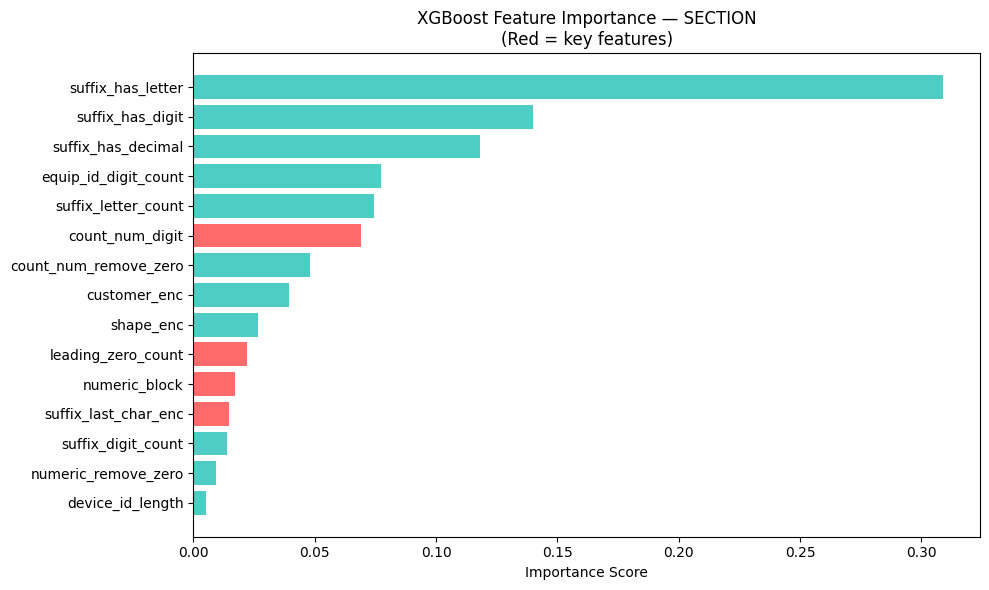


   [CLUSTER]
                   feature  importance
 suffix_last_char_is_digit    0.188706
          suffix_has_digit    0.162005
           count_num_digit    0.076487
              customer_enc    0.065619
             suffix_length    0.055320
      equip_id_digit_count    0.049079
         suffix_has_letter    0.044216
        suffix_has_decimal    0.039719
         suffix_letter_enc    0.034383
       suffix_letter_count    0.032933
      suffix_last_char_enc    0.028797
     count_num_remove_zero    0.026125
         predicted_section    0.023374
        suffix_digit_count    0.022079
suffix_last_char_is_letter    0.021619
         has_suffix_letter    0.020874
          device_id_length    0.020654
                 shape_enc    0.019503
        leading_zero_count    0.018517
           equip_id_length    0.017892
             numeric_block    0.016136
       numeric_remove_zero    0.015963
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000

   Top 10 

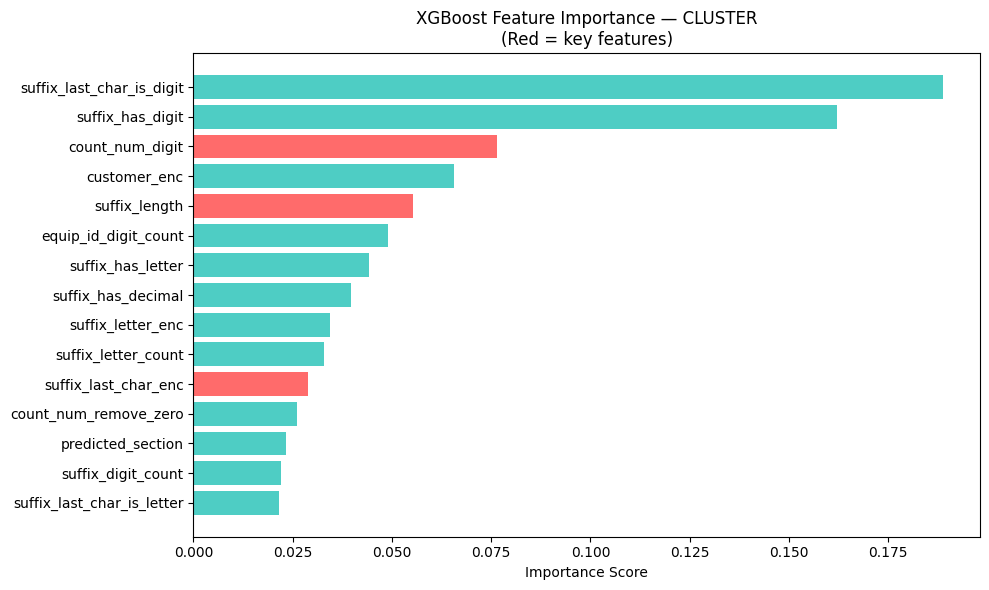

In [13]:
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

key_features = [
    'suffix_last_char_enc',
    'suffix_length',
    'numeric_block',
    'count_num_digit',        # OOD key feature
    'leading_zero_count',     # OOD key feature
]

model_feature_map = {
    "SECTION": (model_section, X_train),
    "CLUSTER": (model_cluster, X_train_chained)
}

for label, (model, X_used) in model_feature_map.items():

    if len(X_used.columns) != len(model.feature_importances_):
        print(f"⚠ Skipping {label}: feature mismatch")
        print(f"   Features: {len(X_used.columns)}, Importances: {len(model.feature_importances_)}")
        continue

    fi = pd.DataFrame({
        'feature'   : X_used.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]")
    print(fi.to_string(index=False))
    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # ── OOD feature activation check ─────────────────────────
    # If these are near-zero, OOD injection did not create the
    # split node. KNN penalty will carry full OOD detection.
    ood_check = ['count_num_digit', 'leading_zero_count', 'count_num_remove_zero']
    print(f"\n   OOD feature importance check:")
    for f in ood_check:
        if f in fi['feature'].values:
            imp    = fi.loc[fi['feature'] == f, 'importance'].values[0]
            status = "✅ active — split node created" if imp > 0.001 else "⚠️  near-zero — KNN penalty carries OOD detection"
            print(f"      {f:30s} : {imp:.6f}  {status}")

    colors = ['#ff6b6b' if f in key_features else '#4ecdc4' for f in fi['feature']]
    fi_top = fi.head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(fi_top['feature'], fi_top['importance'], color=colors[:len(fi_top)])
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



# 9. Save Files

In [14]:
# %%
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

known_customers = set(
    c for c in df['CUSTOMER'].astype(str).unique()
    if c not in ('__OOD__',)
)

pipeline_config = {
    # ── Encoders ─────────────────────────────────────────────
    'le_suffix_letter'       : le_suffix_letter,
    'le_suffix_last'         : le_suffix_last,
    'le_section'             : le_section,
    'le_cluster'             : le_cluster,
    'le_customer'            : le_customer,
    'le_shape'               : le_shape,
    'feature_columns'        : feature_columns,
    'section_features'       : list(X_train.columns),
    'cluster_features'       : list(X_train_chained.columns),
    'known_customers'        : known_customers,
    'known_num_widths'       : known_num_widths_real,
    'reliable_widths'        : reliable_widths,
    'max_num_width'          : max_num_width_real,
    'ood_scaler'             : ood_scaler,
    'ood_knn'                : ood_knn,
    'ood_features'           : OOD_FEATURES,
    'ood_distance_threshold' : ood_threshold,

    # ── Feature importance reference ─────────────────────────
    'key_features'           : key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))

print("\n   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")
print(f"\n   ── Encoders ────────────────────────────────────────")
print(f"   Section classes    : {le_section.real_classes()}")
print(f"   Cluster classes    : {le_cluster.real_classes()}")
print(f"   Shape classes      : {le_shape.real_classes()}")
print(f"\n   ── Features ────────────────────────────────────────")
print(f"   Total features     : {len(feature_columns)}")
print(f"   Section features   : {len(list(X_train.columns))}")
print(f"   Cluster features   : {len(list(X_train_chained.columns))}")
print(f"\n   ── Inference gates ─────────────────────────────────")
print(f"   Known customers    : {sorted(known_customers)}")
print(f"   Max num width      : {max_num_width_real} digits (real data)")
print(f"   Reliable widths    : {sorted(reliable_widths)}")
print(f"\n   ── KNN OOD scorer ──────────────────────────────────")
print(f"   OOD features       : {OOD_FEATURES}")
print(f"   OOD threshold      : {ood_threshold:.4f}")
print(f"   KNN real rows used : {real_mask.sum():,}")
print(f"\n   ── OOD injection ───────────────────────────────────")
print(f"   OOD rows injected  : {n_synthetic}")
print(f"   OOD row width range: {max_num_width_real + 4} – {max_num_width_real + 10} digits")



💾 SAVING MODEL AND ENCODERS

   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl

   ── Encoders ────────────────────────────────────────
   Section classes    : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6')]
   Cluster classes    : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9')]
   Shape classes      : [np.str_('D'), np.str_('DD'), np.str_('DDD'), np.str_('DDDD'), np.str_('DDDDD'), np.str_('DDDDDD'), np.str_('DDDDDL'), np.str_('DDDDL'), np.str_('DDDL'), np.str_('DDDLL'), np.str_('DDLLD'), np.str_('DDLLDD'), np.str_('DDLLDDLL'), np.str_('DDLLDL'), np.str_('DDLLDLL'), np.str_('DDLLLDL')]

   ── Features ────────────────────────────────────────
   Total features     : 23
   Section features   : 23
   Cluster features   : 24

   ── Infer

# End